# Detect Gradual Trends

This notebook introduces PyTrendy’s core features using a synthetic time series with gradual trends. You’ll learn how to load data, visualize trends, detect and rank segments, and extract actionable insights.

![](https://raw.githubusercontent.com/RussellSB/pytrendy/refs/heads/develop/plots/Gradual.gif)

## Installation

Install PyTrendy using pip.

In [1]:
%pip install pytrendy -q

Note: you may need to restart the kernel to use updated packages.


Import the package and alias as `pt`.

In [2]:
import pytrendy as pt

## Load Example Data

PyTrendy comes with built-in synthetic datasets for demonstration. Here, we load a time series with gradual trends. The data covers daily values from 2025-01-01 to 2025-06-30.

In [3]:
# Load a synthetic time series with gradual trends
df = pt.load_data('series_synthetic')[['date', 'gradual']]
df.head()

,date,gradual
0,2025-01-01,12.500000
1,2025-01-02,13.421717
2,2025-01-03,13.474026
3,2025-01-04,13.474026
4,2025-01-05,14.505772


<Axes: xlabel='date'>

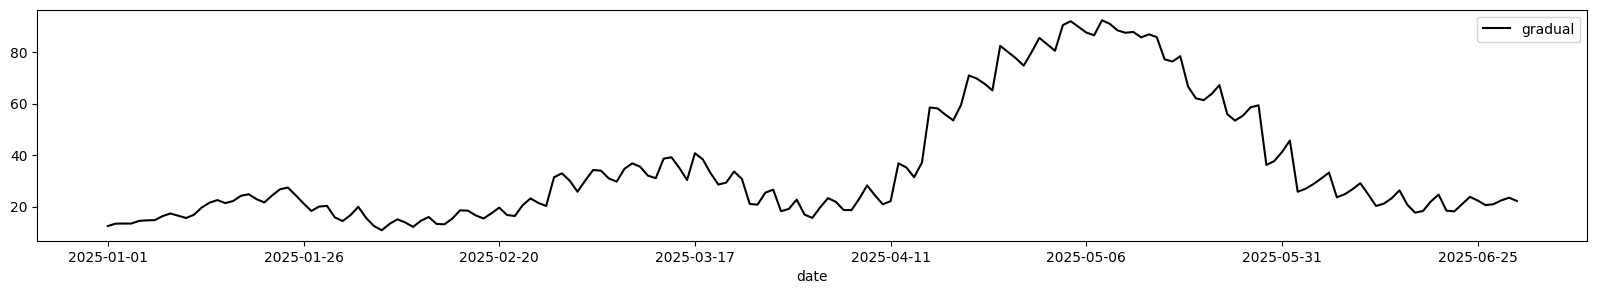

In [4]:
# Visualise the data
df.set_index('date').plot(figsize=(20,3), color='black')

## Detect Trends Automatically

PyTrendy can automatically segment the time series into uptrends, downtrends, flats, and noise. Let’s run the main detection function and plot the results.

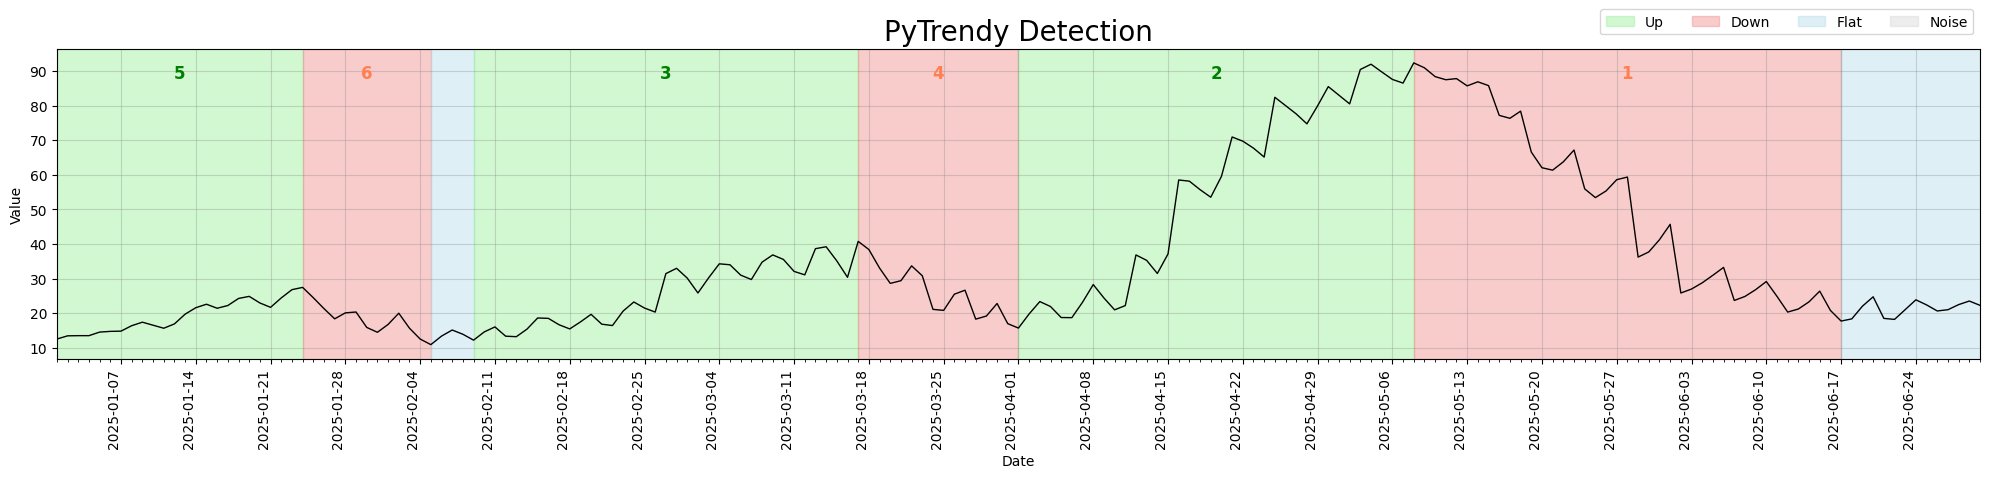

In [5]:
# Detect and plot trends in the time series
results = pt.detect_trends(df, date_col='date', value_col='gradual', plot=True)

Interpreting the above plot:

Coloured segments correspond to `direction`: 
- Green is for `Up`
- Red for `Down`
- Blue for `Flat`
- Gray for `Noise` (though not visible in this example)

Numbered annotations in the centre of each segment refer to `change rank`, e.g.
1. Downtrend is assigned a change rank of `1`, since it is the steepest & longest trend in the dataset.
2. Uptrend a change rank of `2`, though quite a neck-and-neck call, the trend is slightly shorter in day length.
3. Uptrend assigned `3`, since it is much less steep than the uptrend at change rank `2`.
4. Downtrend assigned `4`, since it is much shorter than the downtrend at change rank `3`.

## Detected Trends

Let’s print a summary of the detected segments and see the main statistics.

In [6]:
# Extra setup, only useful for .print_summary() output so it isn't squashed by display width in notebooks
import pandas as pd
pd.set_option('display.width', 100) 

In [7]:
# Print a readable summary of the detected trends
results.print_summary()

Detected: 
- 3 Uptrends. 
- 3 Downtrends.
- 2 Flats.
- 0 Noise.

The best detected trend is Down between dates 2025-05-09 - 2025-06-17

Full Results:
-------------------------------------------------------------------------------
            direction       start         end  days  total_change  change_rank trend_class
time_index                                                                               
1                 Up  2025-01-02  2025-01-24    22     14.013348            5     gradual
2               Down  2025-01-25  2025-02-05    11    -13.564214            6     gradual
3               Flat  2025-02-06  2025-02-09     3     -1.168831            8         NaN
4                 Up  2025-02-10  2025-03-17    35     26.190476            3     gradual
5               Down  2025-03-18  2025-04-01    14    -22.721861            4     gradual
6                 Up  2025-04-02  2025-05-08    36     72.611833            2     gradual
7               Down  2025-05-09  2025-06-17    3

In [8]:
# View the summary DataFrame of all detected segments
results.df_summary

,direction,start,end,days,total_change,change_rank,trend_class
time_index,,,,,,,
1,Up,2025-01-02,2025-01-24,22,14.013348,5,gradual
2,Down,2025-01-25,2025-02-05,11,-13.564214,6,gradual
3,Flat,2025-02-06,2025-02-09,3,-1.168831,8,NaN
4,Up,2025-02-10,2025-03-17,35,26.190476,3,gradual
5,Down,2025-03-18,2025-04-01,14,-22.721861,4,gradual
6,Up,2025-04-02,2025-05-08,36,72.611833,2,gradual
7,Down,2025-05-09,2025-06-17,39,-73.253968,1,gradual
8,Flat,2025-06-18,2025-06-30,12,3.910534,7,NaN


In [9]:
# View the full results DataFrame
results.df

,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
1,Up,2025-01-02,2025-01-24,gradual,14.013348,1.044080,22,14.013348,22.207980,5
2,Down,2025-01-25,2025-02-05,gradual,-13.564214,-0.554982,11,-13.564214,17.360657,6
3,Flat,2025-02-06,2025-02-09,NaN,-1.168831,-0.087591,3,-1.168831,20.126008,8
4,Up,2025-02-10,2025-03-17,gradual,26.190476,1.799257,35,26.190476,18.610749,3
5,Down,2025-03-18,2025-04-01,gradual,-22.721861,-0.591909,14,-22.721861,16.762790,4
6,Up,2025-04-02,2025-05-08,gradual,72.611833,3.675005,36,72.611833,21.701162,2
7,Down,2025-05-09,2025-06-17,gradual,-73.253968,-0.805442,39,-73.253968,21.122099,1
8,Flat,2025-06-18,2025-06-30,NaN,3.910534,0.213344,12,3.910534,19.418124,7


In [10]:
# View the best (strongest) detected trend
results.best

{'direction': 'Down',
 'start': '2025-05-09',
 'end': '2025-06-17',
 'trend_class': 'gradual',
 'change': -73.25396826000001,
 'pct_change': -0.8054420689936198,
 'days': 39,
 'total_change': -73.25396826,
 'SNR': 21.122098999594733,
 'time_index': 7,
 'change_rank': 1}

## Filter Segments

This package doesn't just return results in different formats. It also provides pandas-like functionality to help you narrow down to what you're interested in.

Introducing `.filter_segments()`. These are its key arguments:

- **direction**: Filter by trend direction. Options: `'Any'`, `'Up/Down'`, `'Up'`, `'Down'`, `'Flat'`, `'Noise'`.
- **sort_by**: Sort segments by `'time_index'` (ascending) or `'change_rank'` (descending).
- **format**: Output format. `'df'` returns a DataFrame, `'dict'` returns a list of dictionaries.

In [11]:
# Default params of filter_segments
results.filter_segments(direction='Any', sort_by='time_index', format='df')

,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
1,Up,2025-01-02,2025-01-24,gradual,14.013348,1.044080,22,14.013348,22.207980,5
2,Down,2025-01-25,2025-02-05,gradual,-13.564214,-0.554982,11,-13.564214,17.360657,6
3,Flat,2025-02-06,2025-02-09,NaN,-1.168831,-0.087591,3,-1.168831,20.126008,8
4,Up,2025-02-10,2025-03-17,gradual,26.190476,1.799257,35,26.190476,18.610749,3
5,Down,2025-03-18,2025-04-01,gradual,-22.721861,-0.591909,14,-22.721861,16.762790,4
6,Up,2025-04-02,2025-05-08,gradual,72.611833,3.675005,36,72.611833,21.701162,2
7,Down,2025-05-09,2025-06-17,gradual,-73.253968,-0.805442,39,-73.253968,21.122099,1
8,Flat,2025-06-18,2025-06-30,NaN,3.910534,0.213344,12,3.910534,19.418124,7


This is the default behaviour, synonymous to calling `results.df`. However, there is a lot you can customise with this return. For example, limiting it to the top three uptrends:

In [12]:
# Top 3 uptrends by absolute change
results.filter_segments(direction='Up', sort_by='change_rank')[:3]

,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
6,Up,2025-04-02,2025-05-08,gradual,72.611833,3.675005,36,72.611833,21.701162,2
4,Up,2025-02-10,2025-03-17,gradual,26.190476,1.799257,35,26.190476,18.610749,3
1,Up,2025-01-02,2025-01-24,gradual,14.013348,1.044080,22,14.013348,22.207980,5


Interpreting `pct_change`:
- The largest uptrend segment (2025-04-02 to 2025-05-08) shows a +368% increase. 
- Other strong uptrends occurred from 2025-02-10 to 2025-03-14 (+169%) and 2025-01-02 to 2025-01-24 (+104%). 

PyTrendy makes it easy to spot and rank the most significant changes in your data, with precise date ranges for each segment.

In [13]:
# Top 3 downtrends by absolute change
results.filter_segments(direction='Down', sort_by='change_rank')[:3]

,direction,start,end,trend_class,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
7,Down,2025-05-09,2025-06-17,gradual,-73.253968,-0.805442,39,-73.253968,21.122099,1
5,Down,2025-03-18,2025-04-01,gradual,-22.721861,-0.591909,14,-22.721861,16.762790,4
2,Down,2025-01-25,2025-02-05,gradual,-13.564214,-0.554982,11,-13.564214,17.360657,6


Interpreting `pct_change`:
- The largest downtrend segment (2025-05-09 to 2025-06-17) shows a -81% decrease. 
- Other notable downtrends occurred from 2025-03-18 to 2025-04-01 (-59%) and 2025-01-25 to 2025-02-05 (-55%). 

Other indicators are also available for analysis, e.g. trend_class, total_change, or SNR:
- `trend_class` identifies all trends in this case as "gradual" since the trend is gradually moving. An alternative would be "abrupt", which is expanded on more in the following tutorial.
- `total_change` is the cumulative sum of differences between one day and the next. Using this we can identify that the largest downtrend segment has -73.25, which is just marginally higher in magnitude than the total change of the largest uptrend segment at +72.61. This is why its change rank is placed higher at 1st.
- `SNR` is the signal-to-noise ratio of the segment. A lower SNR indicates a signal is nearly indistinguishable from noise. In this case we have trends with SNR around 20, which is decent.

In [14]:
# Find all flat (stable) periods
results.filter_segments(direction='Flat')

,direction,start,end,change,pct_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,
3,Flat,2025-02-06,2025-02-09,-1.168831,-0.087591,3,-1.168831,20.126008,8
8,Flat,2025-06-18,2025-06-30,3.910534,0.213344,12,3.910534,19.418124,7


Flat periods can be useful for finding quiet baselines or for placebo/AA testing. Here, the longest flat period is 12 days, from 2025-06-18 to 2025-06-30.

## Conclusion

PyTrendy makes trend detection, segmentation, and ranking in time series data fast and scalable. Use it to:
- Automatically find uptrends, downtrends, flats, and noise, with precise date ranges.
- Rank segments by strength and duration.
- Accelerate exploratory data analysis and insight discovery.

Feel free to explore more features in the **Example Gallery**.